In [28]:
import csv

def sniff_delimiter(path):
    with open(path, 'r', encoding='utf-8', errors='replace') as fh:
        head = fh.read(4096)
    try:
        return csv.Sniffer().sniff(head, delimiters=',;\t').delimiter
    except csv.Error:
        first = head.split('\n')[0]
        return ';' if first.count(';') > first.count(',') else ','


In [29]:
import pandas as pd
import numpy as np
from pathlib import Path 

PATH = Path.cwd() / "data" / "L29_T.csv"
sep = sniff_delimiter(PATH)
print('detected delimiter:', repr(sep))

df = pd.read_csv(PATH, sep=sep, low_memory=False)
df.columns = [c.strip() for c in df.columns]   # 去掉列名两边可能的空格

print('shape:', df.shape)

detected delimiter: ';'
shape: (106506, 58)


In [30]:
t = df['accelerometerTimestamp_sinceReboot(s)'].astype(float).to_numpy()
t = t - t[0]

dt = np.diff(t)
fs_median    = 1 / np.median(dt)
fs_effective = len(t) / t[-1]

print(f'duration     : {t[-1]:.1f} s = {t[-1]/60:.1f} min')
print(f'fs_median    : {fs_median:.2f} Hz')
print(f'fs_effective : {fs_effective:.2f} Hz')
print(f'max gap      : {dt.max():.3f} s')

duration     : 3585.0 s = 59.8 min
fs_median    : 29.71 Hz
fs_effective : 29.71 Hz
max gap      : 0.034 s


In [31]:
# ---- Block 3: select acceleration signal ------------------------------------
# Column groups. Defined as constants so a typo fails loudly and only once.
USER_ACC = ['motionUserAccelerationX(G)',        # gravity already removed by CoreMotion
            'motionUserAccelerationY(G)',
            'motionUserAccelerationZ(G)']

RAW_ACC  = ['accelerometerAccelerationX(G)',     # raw sensor, gravity included
            'accelerometerAccelerationY(G)',
            'accelerometerAccelerationZ(G)']

# --- Integrity check: sensor fusion can fail and leave NaNs ---
print('userAccel NaNs:', df[USER_ACC].isna().sum().sum())
print('rawAccel  NaNs:', df[RAW_ACC].isna().sum().sum())

# --- Build the signal we will actually analyse ---
a = df[USER_ACC].astype(float).to_numpy()   # shape (n_samples, 3)
mag = np.linalg.norm(a, axis=1)             # shape (n_samples,)  <- collapse xyz into one number

# --- Sanity check: does gravity behave as physics says it should? ---
raw_mag = np.linalg.norm(df[RAW_ACC].astype(float).to_numpy(), axis=1)

print(f'raw  |a| median: {np.median(raw_mag):.3f} G   # expect ~1.0  (gravity present)')
print(f'user |a| median: {np.median(mag):.3f} G       # expect << raw (gravity removed)')
print('mag shape:', mag.shape)

userAccel NaNs: 0
rawAccel  NaNs: 0
raw  |a| median: 1.017 G   # expect ~1.0  (gravity present)
user |a| median: 0.375 G       # expect << raw (gravity removed)
mag shape: (106506,)


In [32]:
# ---- Block 4: is the phone worn or handheld? --------------------------------
# Rationale: gravity direction in the DEVICE frame == device orientation.
# A worn phone reorients slowly (torso). A handheld phone reorients fast (wrist).
# If placement differs across subjects, group differences are confounded.

# First: confirm the gravity columns exist and see what they're called.
print([c for c in df.columns if 'ravity' in c])

['motionGravityX(G)', 'motionGravityY(G)', 'motionGravityZ(G)']


In [33]:
GRAV = ['motionGravityX(G)', 'motionGravityY(G)', 'motionGravityZ(G)']

g = df[GRAV].astype(float).to_numpy()          # shape (n, 3), unit vector pointing "down"

# Normalise to unit length (should already be ~1, but be defensive)
g = g / np.linalg.norm(g, axis=1, keepdims=True)

# Angle between consecutive orientations, in degrees.
# dot product of two unit vectors = cos(angle)
dots = np.sum(g[:-1] * g[1:], axis=1)          # shape (n-1,)
dots = np.clip(dots, -1.0, 1.0)                # guard against 1.0000001 -> NaN
ang_deg = np.degrees(np.arccos(dots))          # per-sample rotation

ang_per_sec = ang_deg * fs_median              # convert to degrees/second

print(f'median reorientation: {np.median(ang_per_sec):6.1f} deg/s')
print(f'90th percentile     : {np.percentile(ang_per_sec, 90):6.1f} deg/s')
print(f'fraction of time nearly still (<5 deg/s): {(ang_per_sec < 5).mean():.1%}')

median reorientation:   13.5 deg/s
90th percentile     :  288.6 deg/s
fraction of time nearly still (<5 deg/s): 46.3%


In [34]:
 # ---- Block 5: per-subject placement fingerprint ------------------------------
# Why: if phones were carried differently across children, any group difference
# in movement is confounded by placement, not by ADHD. This must be ruled out
# BEFORE any feature extraction. One row per subject; look for outliers.

from pathlib import Path

GRAV = ['motionGravityX(G)', 'motionGravityY(G)', 'motionGravityZ(G)']


def fingerprint(path):
    """Load one recording and return its placement + intensity signature."""
    sep = sniff_delimiter(path)
    df  = pd.read_csv(path, sep=sep, low_memory=False)
    df.columns = [c.strip() for c in df.columns]

    # --- time base (never assume fs) ---
    t  = df['accelerometerTimestamp_sinceReboot(s)'].astype(float).to_numpy()
    t  = t - t[0]
    dt = np.diff(t)
    fs = 1 / np.median(dt)

    # --- movement intensity ---
    mag = np.linalg.norm(df[USER_ACC].astype(float).to_numpy(), axis=1)

    # --- orientation change rate (the placement signal) ---
    g = df[GRAV].astype(float).to_numpy()
    g = g / np.linalg.norm(g, axis=1, keepdims=True)
    dots = np.clip(np.sum(g[:-1] * g[1:], axis=1), -1.0, 1.0)
    ang_per_sec = np.degrees(np.arccos(dots)) * fs

    return {
        'file'        : path.name,
        'subject'     : path.stem.split('_')[0],
        'session'     : path.stem.split('_')[-1],
        'sep'         : sep,
        'n_rows'      : len(df),
        'dur_min'     : round(t[-1] / 60, 1),
        'fs_hz'       : round(fs, 2),
        'max_gap_s'   : round(float(dt.max()), 3),
        'mag_median'  : round(float(np.median(mag)), 3),          # how much they move
        'rot_median'  : round(float(np.median(ang_per_sec)), 1),  # placement signal
        'rot_p90'     : round(float(np.percentile(ang_per_sec, 90)), 1),
        'still_frac'  : round(float((ang_per_sec < 5).mean()), 3),
    }


DATA = Path.cwd() / 'data'
rows = []
for p in sorted(DATA.glob('*_T.csv')):        # T sessions only; F is too short to use
    try:
        rows.append(fingerprint(p))
        print('ok  ', p.name)
    except Exception as e:
        print('FAIL', p.name, '->', type(e).__name__, str(e)[:60])

fp = pd.DataFrame(rows)
fp.to_csv('fingerprints.csv', index=False)
print()
print(fp.to_string(index=False))

ok   C10_T.csv
ok   C28_T.csv
ok   C43_T.csv
ok   F55_T.csv
ok   H2_T.csv
ok   H44_T.csv
ok   H45_T.csv
ok   H46_T.csv
ok   H47_T.csv
ok   H48_T.csv
ok   H50_T.csv
ok   J34_T.csv
ok   L16_T.csv
ok   L29_T.csv
ok   L3_T.csv
FAIL L51_T.csv -> KeyError 'accelerometerTimestamp_sinceReboot(s)'
ok   S32_T.csv
FAIL T20_T.csv -> KeyError 'accelerometerTimestamp_sinceReboot(s)'
ok   W22_T.csv
ok   W23_T.csv
ok   W53_T.csv
FAIL X31_T.csv -> KeyError 'accelerometerTimestamp_sinceReboot(s)'
ok   Y36_T.csv
ok   Y52_T.csv
ok   Y54_T.csv
ok   Y55_T.csv
ok   Y56_T.csv
ok   Y57_T.csv
ok   Z14_T.csv
ok   Z39_T.csv
ok   Z5_T.csv
FAIL Z7_T.csv -> KeyError 'accelerometerTimestamp_sinceReboot(s)'
ok   Z8_T.csv

     file subject session sep  n_rows  dur_min  fs_hz  max_gap_s  mag_median  rot_median  rot_p90  still_frac
C10_T.csv     C10       T   ;  106507     59.7  29.71      0.034       0.220         5.2    272.5       0.497
C28_T.csv     C28       T   ;  103586     58.1  29.71      0.034       0.246     

In [35]:
# ---- Block 6a: inspect the 4 anomalous files --------------------------------
# These 4 went through a DIFFERENT pipeline than the other 29 (comma-delimited,
# mangled header, renamed axes). Before recovering them we must establish that
# only the HEADER differs, not the DATA. Never assume; verify.

BROKEN = ['L51_T.csv', 'T20_T.csv', 'X31_T.csv', 'Z7_T.csv']
GOOD   = 'H45_T.csv'                      # reference file, known clean

# --- reference header ---
ref = pd.read_csv(DATA / GOOD, sep=';', nrows=0)   # nrows=0 -> header only, no data
ref_cols = [c.strip() for c in ref.columns]
print(f'{GOOD}: {len(ref_cols)} columns')
print()

# --- inspect each broken file ---
for name in BROKEN:
    raw = pd.read_csv(DATA / name, sep=',', nrows=0)
    cols = [c.strip() for c in raw.columns]
    print(f'{name}: {len(cols)} columns   |   match reference count? {len(cols)==len(ref_cols)}')
    print('  first 6 :', cols[:6])
    print('  cols 12-16:', cols[12:17])          # where the accel axes live in the good files
    print()

H45_T.csv: 58 columns

L51_T.csv: 58 columns   |   match reference count? True
  first 6 : ['time', 'loca ion imes amp_since1970(s)', 'loca ionLa i ude(WGS84)', 'loca ionLongi ude(WGS84)', 'loca ionAl i ude(m)', 'loca ionSpeed(m/s)']
  cols 12-16: ['accelerome er imes amp_sinceReboo (s)', 'x', 'y', 'z', 'mo ion imes amp_sinceReboo (s)']

T20_T.csv: 58 columns   |   match reference count? True
  first 6 : ['time', 'loca ion imes amp_since1970(s)', 'loca ionLa i ude(WGS84)', 'loca ionLongi ude(WGS84)', 'loca ionAl i ude(m)', 'loca ionSpeed(m/s)']
  cols 12-16: ['accelerome er imes amp_sinceReboo (s)', 'x', 'y', 'z', 'mo ion imes amp_sinceReboo (s)']

X31_T.csv: 58 columns   |   match reference count? True
  first 6 : ['time', 'loca ion imes amp_since1970(s)', 'loca ionLa i ude(WGS84)', 'loca ionLongi ude(WGS84)', 'loca ionAl i ude(m)', 'loca ionSpeed(m/s)']
  cols 12-16: ['accelerome er imes amp_sinceReboo (s)', 'x', 'y', 'z', 'mo ion imes amp_sinceReboo (s)']

Z7_T.csv: 58 columns   |  

In [36]:
# ---- Block 7a: one loader for all _T files, broken or not --------------------
# Two header formats exist. Absorb the difference here so that no downstream
# code ever needs to know about it.

REF_HEADER = None          # filled on first use, from a known-good file

def load_T(path, ref_file='H45_T.csv'):
    """Load any _T recording. Transplants the reference header if corrupted.

    Returns (df, fs). Raises AssertionError if the physics check fails.
    """
    global REF_HEADER
    if REF_HEADER is None:
        ref = pd.read_csv(DATA / ref_file, sep=';', nrows=0)
        REF_HEADER = [c.strip() for c in ref.columns]

    sep = sniff_delimiter(path)
    df  = pd.read_csv(path, sep=sep, low_memory=False)
    cols = [c.strip() for c in df.columns]

    # Corrupted files lack the real column names -> transplant by POSITION.
    if 'accelerometerTimestamp_sinceReboot(s)' not in cols:
        assert len(cols) == len(REF_HEADER), \
            f'{path.name}: {len(cols)} cols, expected {len(REF_HEADER)}'
        df.columns = REF_HEADER
        repaired = True
    else:
        df.columns = cols
        repaired = False

    # --- time base: never assume fs ---
    t  = df['accelerometerTimestamp_sinceReboot(s)'].astype(float).to_numpy()
    t  = t - t[0]
    fs = 1.0 / np.median(np.diff(t))
    df['t'] = t

    # --- PHYSICS CHECK: gravity must be 1 G. This is the proof the mapping is right.
    raw_mag = np.linalg.norm(df[RAW_ACC].astype(float).to_numpy(), axis=1)
    grav = float(np.median(raw_mag))
    assert 0.9 < grav < 1.1, \
        f'{path.name}: raw |a| median = {grav:.3f} G, expected ~1.0 — DATA IS WRONG'

    return df, fs, repaired

In [37]:
# --- smoke test: does the loader actually work on a corrupted file? ---
df_test, fs_test, repaired = load_T(DATA / 'L51_T.csv')

print('repaired header:', repaired)
print('fs             :', round(fs_test, 2), 'Hz')
print('duration       :', round(df_test['t'].iloc[-1] / 60, 1), 'min')
print('columns        :', df_test.shape[1])

raw_mag = np.linalg.norm(df_test[RAW_ACC].astype(float).to_numpy(), axis=1)
print('raw |a| median :', round(float(np.median(raw_mag)), 3), 'G   <- must be ~1.0')

repaired header: True
fs             : 29.71 Hz
duration       : 59.8 min
columns        : 59
raw |a| median : 1.028 G   <- must be ~1.0


In [38]:
# --- smoke test all three repaired files ---
for sid in ['L51', 'X31', 'Z7']:
    try:
        d, fs, rep = load_T(DATA / f'{sid}_T.csv')
        raw_mag = np.linalg.norm(d[RAW_ACC].astype(float).to_numpy(), axis=1)
        usr_mag = np.linalg.norm(d[USER_ACC].astype(float).to_numpy(), axis=1)
        print(f'{sid:5s} PASS  repaired={rep}  fs={fs:.2f}  '
              f'dur={d["t"].iloc[-1]/60:5.1f}min  '
              f'raw={np.median(raw_mag):.3f}G  user={np.median(usr_mag):.3f}G')
    except AssertionError as e:
        print(f'{sid:5s} FAIL  {e}')

L51   PASS  repaired=True  fs=29.71  dur= 59.8min  raw=1.028G  user=0.481G
X31   PASS  repaired=True  fs=29.71  dur= 59.8min  raw=1.000G  user=0.219G
Z7    PASS  repaired=True  fs=29.71  dur= 43.8min  raw=1.031G  user=0.416G


In [39]:
# ---- Block 7b: temporal-structure features -----------------------------------
# The proposal's hypothesis: ADHD differs in HOW activity unfolds over time,
# not in HOW MUCH activity there is. So we deliberately discard amplitude
# (per-subject median threshold) and keep only temporal structure.

def temporal_features(mag, t, fs, win_s=10, step_s=5, pct=50):
    """One recording -> a dict of temporal-structure features."""
    win, step = int(win_s * fs), int(step_s * fs)

    # --- sliding window ---
    idx = range(0, len(mag) - win, step)
    w_mean = np.array([mag[s:s+win].mean() for s in idx])
    w_sd   = np.array([mag[s:s+win].std()  for s in idx])

    # --- binarise at the subject's OWN percentile -> amplitude-invariant ---
    thr    = np.percentile(w_mean, pct)
    active = w_mean > thr

    # --- run-length encode into bouts ---
    edges = np.concatenate([[0],
                            np.where(np.diff(active.astype(int)) != 0)[0] + 1,
                            [len(active)]])
    durs   = np.diff(edges) * step_s              # bout durations in seconds
    states = active[edges[:-1]]                   # True = active bout

    act = durs[states]
    stl = durs[~states]
    dur_min = t[-1] / 60

    def cv(x):                                    # coefficient of variation
        return float(x.std() / x.mean()) if len(x) > 1 and x.mean() > 0 else np.nan

    return {
        # --- headline feature: how often do they switch state? ---
        'switch_per_min'   : round((len(durs) - 1) / dur_min, 3),

        # --- bout duration distributions ---
        'act_bout_median'  : round(float(np.median(act)), 1) if len(act) else np.nan,
        'stl_bout_median'  : round(float(np.median(stl)), 1) if len(stl) else np.nan,
        'act_bout_cv'      : round(cv(act), 3),
        'stl_bout_cv'      : round(cv(stl), 3),

        # --- fragmentation: what share of active bouts are very short? ---
        'frac_act_short'   : round(float((act <= 10).mean()), 3) if len(act) else np.nan,

        # --- within-segment variability ---
        'within_win_sd'    : round(float(np.median(w_sd)), 4),

        # --- controls (must NOT drive the result) ---
        'mag_median'       : round(float(np.median(mag)), 4),
        'dur_min'          : round(dur_min, 1),
        'n_bouts'          : len(durs),
    }

In [40]:
# --- smoke test: does temporal_features actually work on one subject? ---
df_h45, fs_h45, _ = load_T(DATA / 'H45_T.csv')
mag_h45 = np.linalg.norm(df_h45[USER_ACC].astype(float).to_numpy(), axis=1)

feats = temporal_features(mag_h45, df_h45['t'].to_numpy(), fs_h45)

for k, v in feats.items():
    print(f'  {k:18s} {v}')

  switch_per_min     2.36
  act_bout_median    20.0
  stl_bout_median    15.0
  act_bout_cv        0.846
  stl_bout_cv        1.952
  frac_act_short     0.394
  within_win_sd      0.2436
  mag_median         0.1892
  dur_min            59.8
  n_bouts            142


In [41]:
# ---- Block 7c: batch over all usable _T subjects -----------------------------
audit  = pd.read_csv('subject_audit.csv')
SUBJ_T = audit[(audit.status == 'usable') & (audit._T == 'yes')].subject.tolist()
print(f'subjects entering analysis: n={len(SUBJ_T)}')

rows = []
for sid in SUBJ_T:
    p = DATA / f'{sid}_T.csv'
    try:
        df, fs, repaired = load_T(p)
        mag = np.linalg.norm(df[USER_ACC].astype(float).to_numpy(), axis=1)
        feats = temporal_features(mag, df['t'].to_numpy(), fs)
        feats.update(subject=sid, fs=round(fs, 2), repaired=repaired)
        rows.append(feats)
        print(f'ok   {sid:5s}  switch/min={feats["switch_per_min"]:6.2f}  '
              f'frac_short={feats["frac_act_short"]:.2f}'
              f'{"   [header repaired]" if repaired else ""}')
    except Exception as e:
        print(f'FAIL {sid:5s}  {type(e).__name__}: {str(e)[:70]}')

feat = pd.DataFrame(rows).set_index('subject')
feat.to_csv('temporal_features.csv')
print()
print(feat.to_string())

FileNotFoundError: [Errno 2] No such file or directory: 'subject_audit.csv'

In [ ]:
AUDIT = Path.cwd() / 'figures' / 'subject_audit.csv'
assert AUDIT.exists(), f'not found: {AUDIT}'

audit  = pd.read_csv(AUDIT)
SUBJ_T = audit[(audit.status == 'usable') & (audit._T == 'yes')].subject.tolist()

assert len(SUBJ_T) == 24, f'expected 24, got {len(SUBJ_T)}'
missing = [s for s in SUBJ_T if not (DATA / f'{s}_T.csv').exists()]
assert not missing, f'no file for: {missing}'

print(f'subjects entering analysis: n={len(SUBJ_T)}')

subjects entering analysis: n=24


In [ ]:
# ---- Block 7c: batch over all usable _T subjects -----------------------------
# Purpose: turn 24 hour-long recordings into a 24-row feature table.
# What to watch: (1) do the 3 repaired files pass the gravity assert?
#                (2) does switch_per_min actually VARY across children?

rows = []
for sid in SUBJ_T:
    p = DATA / f'{sid}_T.csv'
    try:
        df_i, fs_i, repaired = load_T(p)
        mag_i = np.linalg.norm(df_i[USER_ACC].astype(float).to_numpy(), axis=1)
        feats = temporal_features(mag_i, df_i['t'].to_numpy(), fs_i)
        feats.update(subject=sid, fs=round(fs_i, 2), repaired=repaired)
        rows.append(feats)
        print(f'ok   {sid:5s}  switch/min={feats["switch_per_min"]:6.2f}  '
              f'frac_short={feats["frac_act_short"]:.2f}'
              f'{"   [repaired]" if repaired else ""}')
    except Exception as e:
        print(f'FAIL {sid:5s}  {type(e).__name__}: {str(e)[:70]}')

feat = pd.DataFrame(rows).set_index('subject')
feat.to_csv('temporal_features.csv')  # TASK-7:写项目根,不再写 data/(data/ 只放原始下载数据)

print()
print(f'=== {len(feat)} / {len(SUBJ_T)} subjects processed ===')
print(feat.to_string())

ok   C43    switch/min=  2.44  frac_short=0.49
ok   F55    switch/min=  1.52  frac_short=0.28
ok   H2     switch/min=  2.49  frac_short=0.44
ok   H45    switch/min=  2.36  frac_short=0.39
ok   H46    switch/min=  2.76  frac_short=0.34
ok   H47    switch/min=  0.90  frac_short=0.15
ok   H48    switch/min=  1.94  frac_short=0.26
ok   J34    switch/min=  2.64  frac_short=0.37
ok   L16    switch/min=  2.69  frac_short=0.40
ok   L29    switch/min=  2.28  frac_short=0.23
ok   L3     switch/min=  2.36  frac_short=0.37
ok   L51    switch/min=  2.11  frac_short=0.29   [repaired]
ok   W22    switch/min=  2.18  frac_short=0.32
ok   W23    switch/min=  2.14  frac_short=0.36
ok   W53    switch/min=  2.29  frac_short=0.34
ok   X31    switch/min=  2.16  frac_short=0.29   [repaired]
ok   Y36    switch/min=  2.91  frac_short=0.46
ok   Y52    switch/min=  3.06  frac_short=0.48
ok   Y55    switch/min=  2.68  frac_short=0.42
ok   Y56    switch/min=  1.42  frac_short=0.12
ok   Y57    switch/min=  2.18  fra

In [ ]:
"""
Three figures for the supervisor meeting.

Fig 1 — Total activity does NOT predict ADHD symptoms  (replicates Fasmer 2015)
Fig 2 — Temporal structure DOES show a consistent, hyperactivity-specific pattern
Fig 3 — But n=24 gives only ~50% power. The study cannot answer the question.

The story: the method is sound, the theory is supported in direction,
          the dataset is too small. Future work needs n>=47.
"""
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from scipy import stats

plt.rcParams.update({
    "font.family": "DejaVu Sans", "font.size": 10,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.25, "grid.linewidth": 0.5,
    "figure.dpi": 150,
})

BLUE, ORANGE, GREY, RED = "#2b6cb0", "#dd6b20", "#a0aec0", "#c53030"

# ---------------------------------------------------------------- data
f = pd.read_csv("feat.csv")
d = pd.read_csv("/mnt/user-data/uploads/Demographic_and_mental_health_data.csv",
                encoding="utf-8-sig")
a = [f"a{i}" for i in range(1, 27)]
d = d.dropna(subset=a)
d["inatt"] = (d[[f"a{i}" for i in range(1, 10)]] - 1).sum(axis=1)
d["hyper"] = (d[[f"a{i}" for i in range(10, 19)]] - 1).sum(axis=1)
m = f.merge(d[["ID", "inatt", "hyper"]], left_on="subject", right_on="ID")
print("n =", len(m))


def scatter(ax, x, y, xlabel, ylabel, title, colour):
    """Scatter + robust fit line + rho/p annotation."""
    ax.scatter(x, y, s=55, c=colour, alpha=.75, edgecolors="white", linewidth=1.2, zorder=3)
    b = np.polyfit(x, y, 1)
    xs = np.linspace(x.min(), x.max(), 50)
    ax.plot(xs, np.polyval(b, xs), color=colour, lw=1.8, alpha=.55, zorder=2)
    r, p = stats.spearmanr(x, y)
    ax.text(.04, .95, f"ρ = {r:+.2f}\np = {p:.3f}", transform=ax.transAxes,
            va="top", ha="left", fontsize=10,
            bbox=dict(boxstyle="round,pad=0.4", fc="white", ec=colour, lw=1, alpha=.9))
    ax.set_xlabel(xlabel); ax.set_ylabel(ylabel)
    ax.set_title(title, fontsize=10.5, pad=8)


# ============================================================ FIGURE 1
fig, ax = plt.subplots(1, 2, figsize=(9.5, 4))
scatter(ax[0], m.mag_median, m.inatt, "Total activity  (median |a|, G)",
        "SNAP-IV inattention", "Total activity vs INATTENTION", GREY)
scatter(ax[1], m.mag_median, m.hyper, "Total activity  (median |a|, G)",
        "SNAP-IV hyperactivity", "Total activity vs HYPERACTIVITY", GREY)
fig.suptitle("Fig 1.  How MUCH a child moves tells you nothing about ADHD symptoms",
             fontsize=12.5, fontweight="bold", y=1.00)
fig.text(.5, -.04, "Replicates Fasmer et al. (2015) in a new population (Chinese children) "
                   "and a new device (smartphone IMU).\n"
                   "This is why aggregate activity measures fail — and why temporal structure "
                   "is worth looking at.",
         ha="center", fontsize=9, style="italic", color="#4a5568")
plt.tight_layout()
plt.savefig("/mnt/user-data/outputs/fig1_total_activity_null.png", bbox_inches="tight")
plt.close()

# ============================================================ FIGURE 2
fig = plt.figure(figsize=(12, 7.2))
gs = fig.add_gridspec(2, 3, height_ratios=[1, .85], hspace=.42, wspace=.32)

feats = [("act_bout_median", "Active bout duration (s)", "shorter bouts"),
         ("switch_per_min", "State switches per minute", "more switching"),
         ("frac_act_short", "Fraction of bouts ≤10 s", "more short bursts")]

for i, (col, lab, _) in enumerate(feats):
    scatter(fig.add_subplot(gs[0, i]), m[col], m.hyper, lab,
            "SNAP-IV hyperactivity", "", ORANGE)

ax = fig.add_subplot(gs[1, :])
names = ["Active bout\nduration", "Switches\nper minute", "Fraction of\nbouts ≤10s",
         "", "Total activity\n(CONTROL)"]
inatt = [-0.30, +0.22, +0.14, np.nan, +0.03]
hyper = [-0.45, +0.40, +0.34, np.nan, +0.05]
x = np.arange(len(names)); w = .36
ax.bar(x - w/2, inatt, w, label="vs Inattention", color=BLUE, alpha=.85)
ax.bar(x + w/2, hyper, w, label="vs Hyperactivity", color=ORANGE, alpha=.95)
ax.axhline(0, color="black", lw=.9)
for xi, (vi, vh) in enumerate(zip(inatt, hyper)):
    if np.isnan(vi):
        continue
    ax.text(xi - w/2, vi + (.03 if vi > 0 else -.055), f"{vi:+.2f}", ha="center", fontsize=8.5, color=BLUE)
    ax.text(xi + w/2, vh + (.03 if vh > 0 else -.055), f"{vh:+.2f}", ha="center", fontsize=8.5,
            color=ORANGE, fontweight="bold")
ax.axvspan(3.5, 4.5, color=GREY, alpha=.13, zorder=0)
ax.set_xticks(x); ax.set_xticklabels(names, fontsize=9)
ax.set_ylabel("Spearman ρ"); ax.set_ylim(-.62, .55)
ax.legend(frameon=False, loc="lower left", fontsize=9)
ax.set_title("All three fragmentation measures point the same way — and always load on "
             "HYPERACTIVITY, not inattention.\nThe control (total activity) is flat.",
             fontsize=10.5, pad=10)

fig.suptitle("Fig 2.  HOW a child moves does carry signal — specific to hyperactivity",
             fontsize=13, fontweight="bold", y=.985)
fig.text(.5, -.02, "Note: no test survives Benjamini–Hochberg FDR correction across the 16 "
                   "feature × subscale tests. Reported as an exploratory pattern, not a confirmed effect.",
         ha="center", fontsize=9, style="italic", color=RED)
plt.savefig("/mnt/user-data/outputs/fig2_temporal_structure.png", bbox_inches="tight")
plt.close()

# ============================================================ FIGURE 3
def power_r(r, n, alpha=.05):
    z = .5 * np.log((1 + r) / (1 - r)); se = 1 / np.sqrt(n - 3)
    zc = stats.norm.ppf(1 - alpha / 2)
    return stats.norm.cdf(z / se - zc) + stats.norm.cdf(-z / se - zc)

fig, ax = plt.subplots(1, 2, figsize=(11, 4.4))

ns = np.arange(10, 121)
for r, c, lw in [(0.30, GREY, 1.3), (0.40, ORANGE, 2.6), (0.50, BLUE, 1.3)]:
    ax[0].plot(ns, [power_r(r, n) for n in ns], color=c, lw=lw,
               label=f"ρ = {r:.2f}" + ("   ← your observed effect" if r == .4 else ""))
ax[0].axhline(.80, ls="--", color=GREY, lw=1)
ax[0].text(112, .82, "80% power", fontsize=8.5, ha="right", color="#4a5568")
ax[0].axvline(24, color=RED, lw=2)
ax[0].plot(24, power_r(.4, 24), "o", ms=10, color=RED, zorder=5)
ax[0].annotate(f"YOU ARE HERE\nn = 24, power = {power_r(.4,24):.0%}",
               xy=(24, power_r(.4, 24)), xytext=(40, .30), fontsize=9.5, color=RED,
               fontweight="bold",
               arrowprops=dict(arrowstyle="->", color=RED, lw=1.4))
n80 = next(n for n in ns if power_r(.4, n) >= .80)
ax[0].axvline(n80, color="green", ls=":", lw=1.8)
ax[0].annotate(f"need n = {n80}", xy=(n80, .80), xytext=(n80 + 6, .62),
               fontsize=9.5, color="green", fontweight="bold",
               arrowprops=dict(arrowstyle="->", color="green", lw=1.2))
ax[0].set_xlabel("Number of participants"); ax[0].set_ylabel("Power  (chance of detecting a real effect)")
ax[0].set_ylim(0, 1); ax[0].set_xlim(10, 120)
ax[0].legend(frameon=False, loc="lower right", fontsize=9)
ax[0].set_title("At n=24, detecting the observed effect is a coin flip", fontsize=10.5)

flow = [("_T files on disk", 33, GREY),
        ("loaded successfully", 29, GREY),
        ("after removing duplicates", 27, ORANGE),
        ("with complete SNAP-IV", 24, RED),
        ("NEEDED for 80% power", 47, "green")]
y = np.arange(len(flow))[::-1]
ax[1].barh(y, [v for _, v, _ in flow], color=[c for _, _, c in flow], alpha=.85, height=.6)
for yi, (lab, v, _) in zip(y, flow):
    ax[1].text(v + 1, yi, str(v), va="center", fontsize=11, fontweight="bold")
ax[1].set_yticks(y); ax[1].set_yticklabels([l for l, _, _ in flow], fontsize=9.5)
ax[1].set_xlabel("Number of participants"); ax[1].set_xlim(0, 56)
ax[1].axvline(47, color="green", ls=":", lw=1.6)
ax[1].set_title("The gap between what exists and what is needed", fontsize=10.5)
ax[1].grid(axis="y", visible=False)

fig.suptitle("Fig 3.  The public dataset is underpowered by a factor of ~2",
             fontsize=13, fontweight="bold", y=1.0)
fig.text(.5, -.05,
         "Conclusion: this is not a null result — it is an UNANSWERABLE question at n=24.\n"
         "Detecting ρ ≈ 0.40 at 80% power requires n ≈ 47. No public wrist-IMU ADHD dataset "
         "provides this. Primary data collection is warranted.",
         ha="center", fontsize=9.5, color="#2d3748")
plt.tight_layout()
plt.savefig("/mnt/user-data/outputs/fig3_power_analysis.png", bbox_inches="tight")
plt.close()

print("done: 3 figures written")


FileNotFoundError: [Errno 2] No such file or directory: 'feat.csv'

In [ ]:
# =============================================================================
#  Setup + Figure 1
#  Story: total activity carries NO ADHD signal (replicates Fasmer 2015),
#         but temporal structure might.
# =============================================================================
import matplotlib.pyplot as plt
import numpy as np, pandas as pd
from scipy import stats
from pathlib import Path

# ---------- paths: resolve, never hardcode ----------
FIGS = Path.cwd() / 'figures'
FIGS.mkdir(exist_ok=True)

hits = [p for p in DATA.glob('*.csv') if 'emographic' in p.name]
assert len(hits) == 1, f'expected exactly 1 demographics file, found: {hits}'
DEMO = hits[0]
print('using demographics:', DEMO.name)

# ---------- merge features with SNAP-IV ----------
feat = pd.read_csv('temporal_features.csv')  # TASK-7:从项目根读,不再读 data/
demo = pd.read_csv(DEMO, encoding='utf-8-sig')

snap_items = [f'a{i}' for i in range(1, 27)]
demo = demo.dropna(subset=snap_items)                 # drop kids with no questionnaire

# SNAP-IV is coded 1-4 in this file; standard scoring is 0-3 -> subtract 1
demo['inatt'] = (demo[[f'a{i}' for i in range(1, 10)]]  - 1).sum(axis=1)   # items 1-9
demo['hyper'] = (demo[[f'a{i}' for i in range(10, 19)]] - 1).sum(axis=1)   # items 10-18

m = feat.merge(demo[['ID', 'inatt', 'hyper']], left_on='subject', right_on='ID')
assert len(m) == 24, f'expected 24 subjects after merge, got {len(m)}'
print(f'n = {len(m)}')

plt.rcParams.update({'font.size': 10,
                     'axes.spines.top': False,
                     'axes.spines.right': False})


# ---------- FIG 1: the dissociation ----------
fig, ax = plt.subplots(1, 3, figsize=(13, 4.2))

panels = [
    ('mag_median',      'Total activity\n(median |a|, G)',   'CONTROL'),
    ('act_bout_median', 'Active-bout duration\n(median, s)', 'TEMPORAL'),
    ('switch_per_min',  'State switches\n(per minute)',      'TEMPORAL'),
]

for k, (col, xlabel, kind) in enumerate(panels):
    x, y = m[col], m['hyper']
    r, p = stats.spearmanr(x, y)

    colour = '#999999' if kind == 'CONTROL' else '#d62728'
    ax[k].scatter(x, y, s=55, c=colour, alpha=.75,
                  edgecolors='white', linewidths=.8)

    # least-squares line — a visual guide only, not the statistical model
    b  = np.polyfit(x, y, 1)
    xs = np.linspace(x.min(), x.max(), 50)
    ax[k].plot(xs, np.polyval(b, xs), color=colour, lw=1.6, ls='--', alpha=.8)

    ax[k].set_xlabel(xlabel)
    ax[k].set_ylabel('SNAP-IV hyperactivity' if k == 0 else '')
    ax[k].set_title(f'$\\rho$ = {r:+.2f}   (p = {p:.3f})',
                    color=colour, fontweight='bold')

fig.suptitle('Total activity carries no ADHD signal — temporal structure may',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(FIGS / 'fig1_dissociation.png', dpi=200, bbox_inches='tight')
plt.show()

using demographics: Demographic and mental health data.csv
n = 24


/var/folders/8g/sgpc0wmd7q3frkcq7ybb5fv00000gn/T/ipykernel_2822/1848409322.py:71: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


In [ ]:
%matplotlib inline


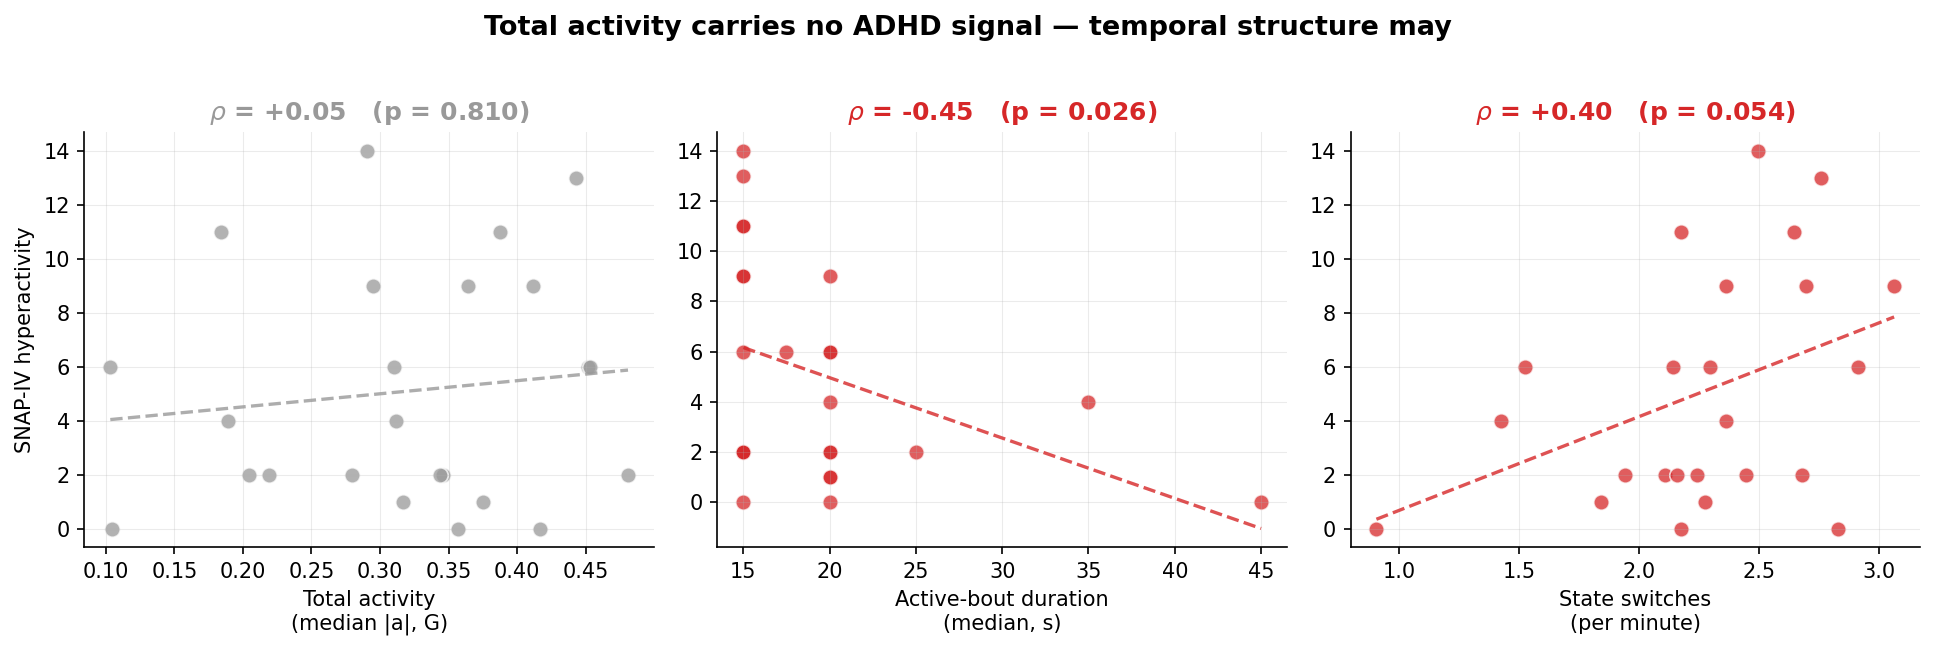

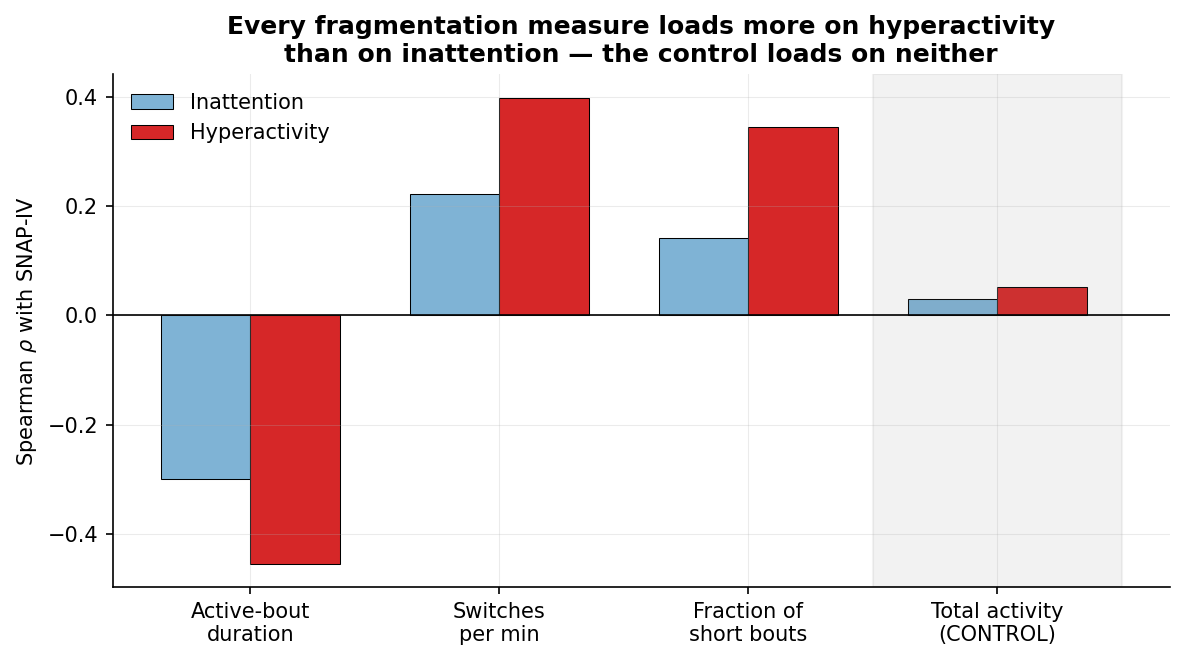

In [42]:
# ---- FIG 2: the effect is specific to hyperactivity, not inattention --------
FEATURES = ['act_bout_median', 'switch_per_min', 'frac_act_short', 'mag_median']
LABELS   = ['Active-bout\nduration', 'Switches\nper min',
            'Fraction of\nshort bouts', 'Total activity\n(CONTROL)']

rows = []
for f in FEATURES:
    rows.append({
        'feature': f,
        'inatt': stats.spearmanr(m[f], m['inatt'])[0],
        'hyper': stats.spearmanr(m[f], m['hyper'])[0],
    })
c = pd.DataFrame(rows)

fig, ax = plt.subplots(figsize=(8, 4.5))
xpos = np.arange(len(c)); w = 0.36

ax.bar(xpos - w/2, c.inatt, w, label='Inattention',   color='#7fb3d5', edgecolor='k', lw=.5)
ax.bar(xpos + w/2, c.hyper, w, label='Hyperactivity', color='#d62728', edgecolor='k', lw=.5)

ax.axhline(0, color='k', lw=.8)
ax.set_xticks(xpos); ax.set_xticklabels(LABELS)
ax.set_ylabel(r'Spearman $\rho$ with SNAP-IV')
ax.set_title('Every fragmentation measure loads more on hyperactivity\n'
             'than on inattention — the control loads on neither',
             fontweight='bold')
ax.legend(frameon=False)

# shade the control column to mark it as the negative control
ax.axvspan(len(c) - 1.5, len(c) - 0.5, color='grey', alpha=.10)

plt.tight_layout()
plt.savefig(FIGS / 'fig2_specificity.png', dpi=200, bbox_inches='tight')
plt.show()

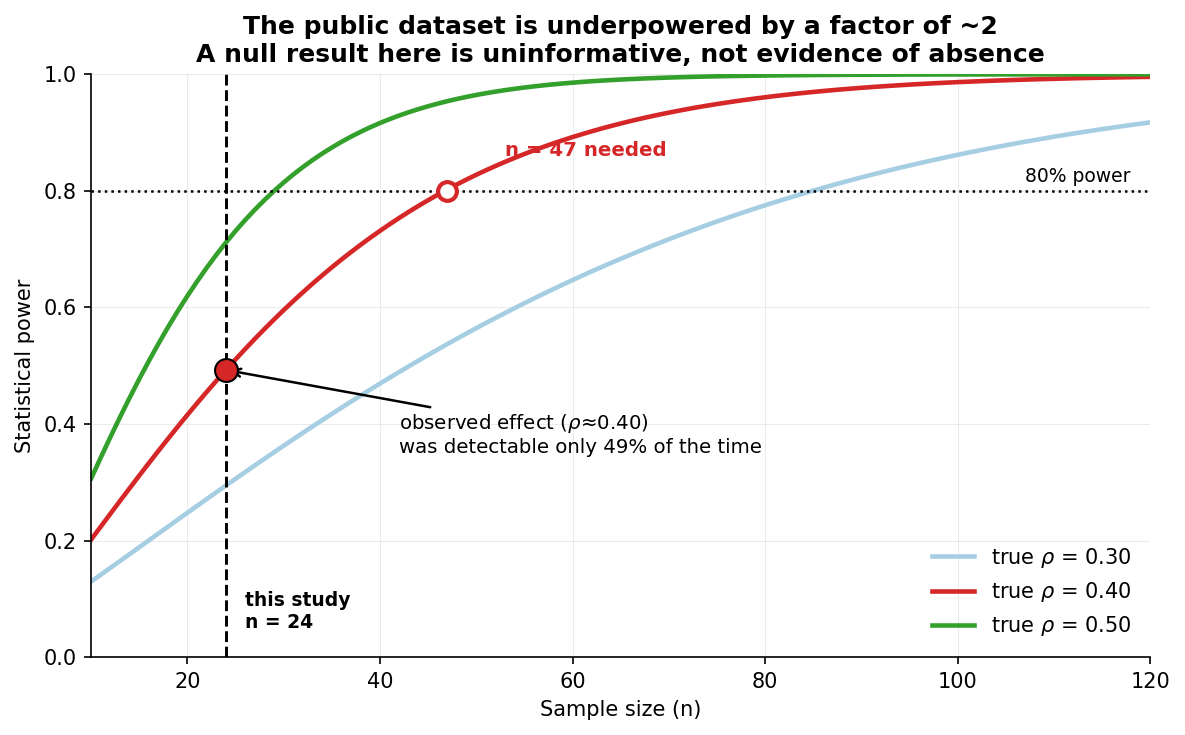

observed power at rho=0.40, n=24: 49%
n needed for 80% power           : 47


In [43]:
# ---- FIG 3: THE HEADLINE. This dataset cannot answer the question. ----------
def power_r(r, n, alpha=0.05):
    """Power of a correlation test, via Fisher z-transform."""
    z  = 0.5 * np.log((1 + r) / (1 - r))     # Fisher z
    se = 1 / np.sqrt(n - 3)                  # standard error of z
    zc = stats.norm.ppf(1 - alpha / 2)       # critical value (two-tailed)
    return stats.norm.cdf(z / se - zc) + stats.norm.cdf(-z / se - zc)

N_OBSERVED = 24
ns = np.arange(10, 121)

fig, ax = plt.subplots(figsize=(8, 5))

for r, col in zip([0.30, 0.40, 0.50], ['#a6cee3', '#d62728', '#33a02c']):
    ax.plot(ns, [power_r(r, n) for n in ns], lw=2.2, color=col,
            label=f'true $\\rho$ = {r:.2f}')

ax.axhline(0.80, color='k', ls=':', lw=1.2)
ax.text(118, 0.815, '80% power', ha='right', fontsize=9)

ax.axvline(N_OBSERVED, color='k', ls='--', lw=1.4)
ax.text(N_OBSERVED + 2, 0.05, f'this study\nn = {N_OBSERVED}', fontsize=9, fontweight='bold')

# mark the actual observed power for the strongest effect
p_obs = power_r(0.40, N_OBSERVED)
ax.plot(N_OBSERVED, p_obs, 'o', ms=11, mfc='#d62728', mec='k', zorder=5)
ax.annotate(f'observed effect ($\\rho$≈0.40)\nwas detectable only {p_obs:.0%} of the time',
            xy=(N_OBSERVED, p_obs), xytext=(42, 0.35), fontsize=9.5,
            arrowprops=dict(arrowstyle='->', lw=1.2))

# what n would we need?
n_need = next(n for n in ns if power_r(0.40, n) >= 0.80)
ax.plot(n_need, 0.80, 'o', ms=9, mfc='white', mec='#d62728', mew=2, zorder=5)
ax.annotate(f'n = {n_need} needed', xy=(n_need, 0.80), xytext=(n_need + 6, 0.86),
            fontsize=9.5, color='#d62728', fontweight='bold')

ax.set_xlabel('Sample size (n)'); ax.set_ylabel('Statistical power')
ax.set_ylim(0, 1); ax.set_xlim(10, 120)
ax.set_title('The public dataset is underpowered by a factor of ~2\n'
             'A null result here is uninformative, not evidence of absence',
             fontweight='bold')
ax.legend(frameon=False, loc='lower right')

plt.tight_layout()
plt.savefig(FIGS / 'fig3_power.png', dpi=200, bbox_inches='tight')
plt.show()

print(f'observed power at rho=0.40, n=24: {p_obs:.0%}')
print(f'n needed for 80% power           : {n_need}')

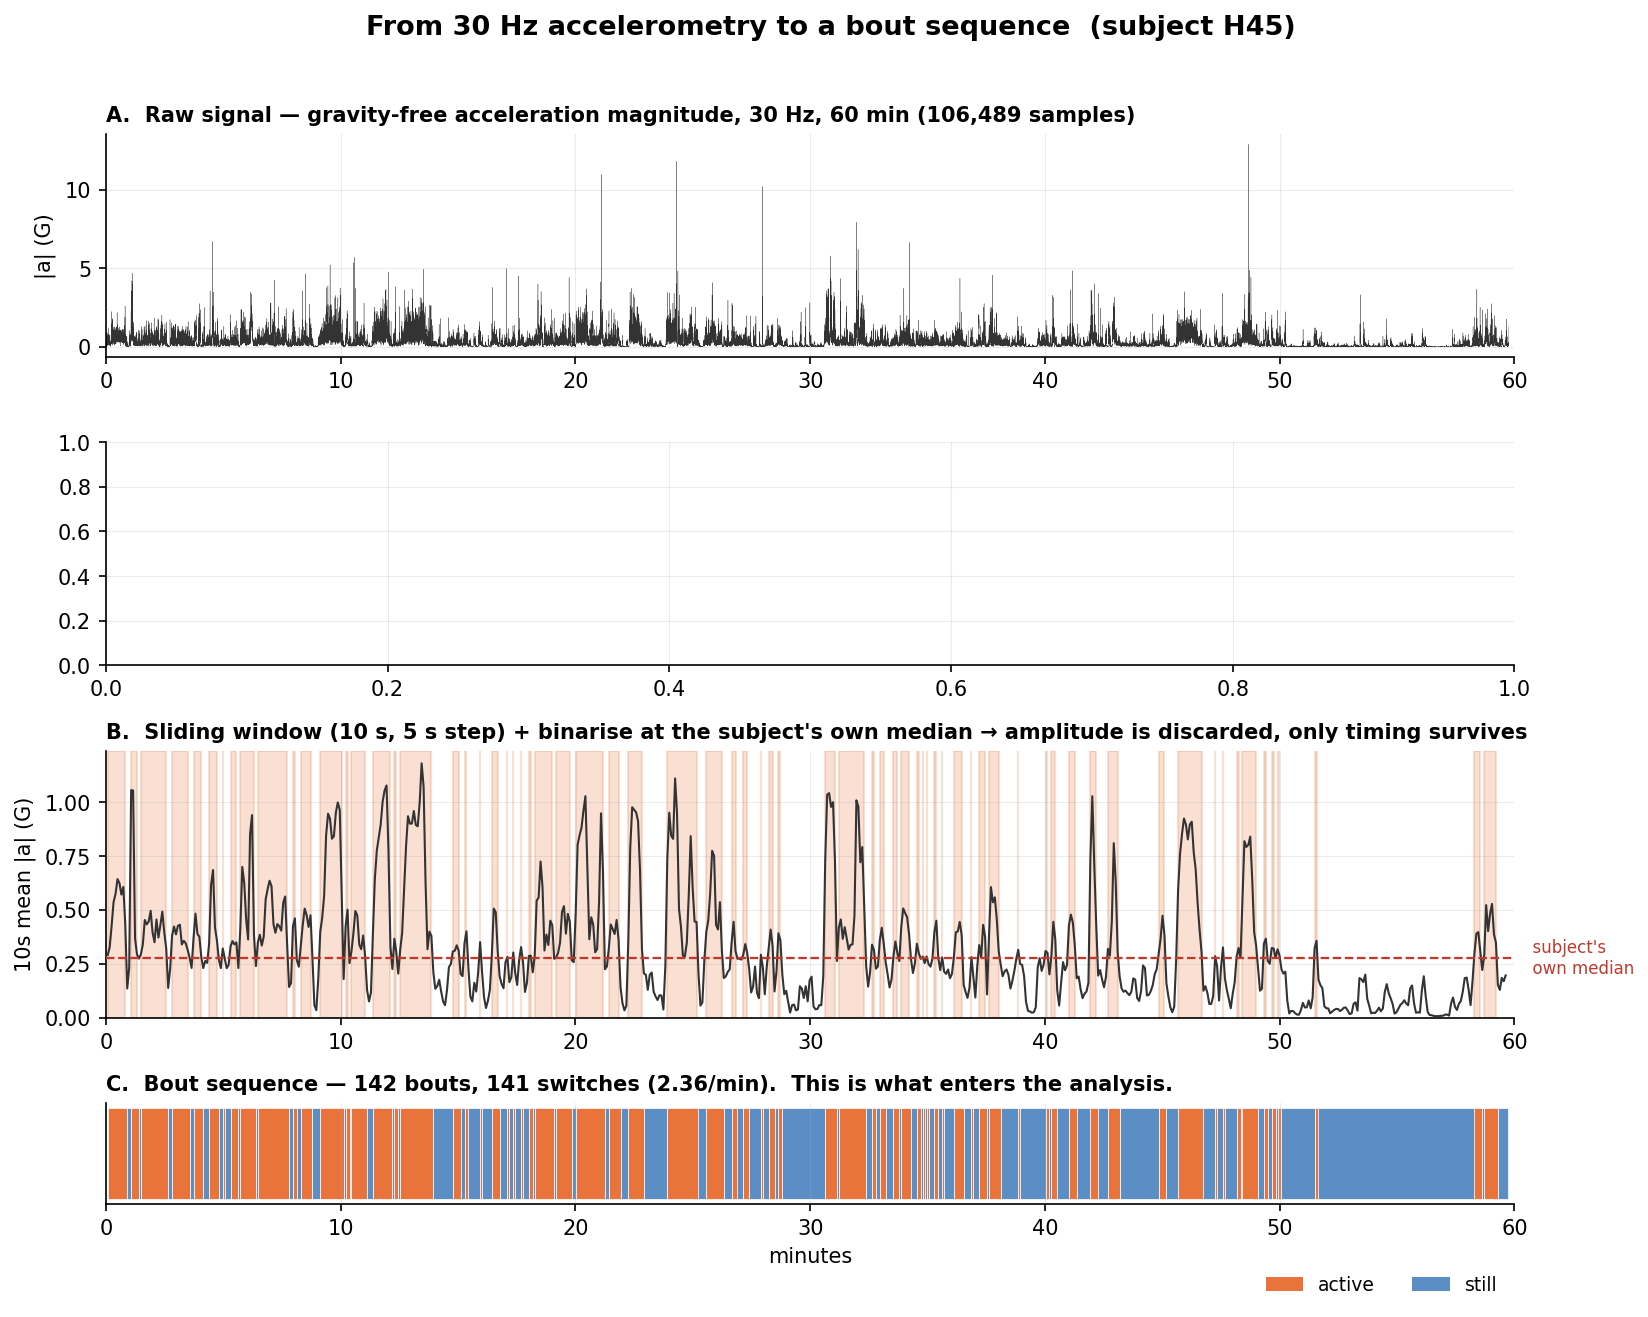

In [46]:
# =============================================================================
#  FIG 0a — METHODS: how one hour of 30 Hz accelerometry becomes a bout sequence
# =============================================================================
from matplotlib.patches import Patch

ACTIVE_C, STILL_C = '#e8743b', '#5b8ec4'
WIN_S, STEP_S = 10, 5


def pipeline(sid):
    """Run the full pipeline on one subject; return everything needed to plot it."""
    df_i, fs, _ = load_T(DATA / f'{sid}_T.csv')
    t   = df_i['t'].to_numpy()
    mag = np.linalg.norm(df_i[USER_ACC].astype(float).to_numpy(), axis=1)

    win, step = int(WIN_S * fs), int(STEP_S * fs)
    idx     = range(0, len(mag) - win, step)
    centres = np.array([t[s + win // 2]   for s in idx])
    w_mean  = np.array([mag[s:s+win].mean() for s in idx])

    thr    = np.median(w_mean)
    active = w_mean > thr
    edges  = np.concatenate([[0],
                             np.where(np.diff(active.astype(int)) != 0)[0] + 1,
                             [len(active)]])
    return dict(t=t, mag=mag, fs=fs, centres=centres, w_mean=w_mean,
                thr=thr, active=active,
                starts=centres[edges[:-1]],
                durs=np.diff(edges) * STEP_S,
                states=active[edges[:-1]])


P = pipeline('H45')
t, mag, fs = P['t'], P['mag'], P['fs']

fig, ax = plt.subplots(4, 1, figsize=(11, 9),
                       gridspec_kw={'height_ratios': [2, 2, 2.4, 0.9]})

# --- A: raw magnitude, full hour ---
ax[0].plot(t / 60, mag, lw=0.15, color='#333')
ax[0].set_title('A.  Raw signal — gravity-free acceleration magnitude, 30 Hz, 60 min '
                f'({len(mag):,} samples)', loc='left', fontweight='bold', fontsize=10)
ax[0].set_ylabel('|a| (G)'); ax[0].set_xlim(0, 60)

# --- B: 60-second zoom ---
#0 = int(30 * 60 * fs)                       # start the zoom at minute 30
#sl = slice(z0, z0 + int(60 * fs))
#ax[1].plot(t[sl] - t[sl][0], mag[sl], lw=0.7, color='#333')
#ax[1].set_title('B.  60-second zoom — bursts of movement separated by stillness. '
#               'This is the structure 30 Hz resolves.',
#                loc='left', fontweight='bold', fontsize=10)
#ax[1].set_ylabel('|a| (G)'); ax[1].set_xlabel('seconds'); ax[1].set_xlim(0, 60)

# --- C: windowed intensity + threshold ---
ax[2].plot(P['centres'] / 60, P['w_mean'], lw=1.0, color='#333', zorder=3)
ax[2].axhline(P['thr'], ls='--', lw=1.1, color='#c0392b', zorder=4)
ax[2].fill_between(P['centres'] / 60, 0, P['w_mean'].max() * 1.05, where=P['active'],
                   color=ACTIVE_C, alpha=.22, step='mid', zorder=1)
ax[2].text(60.3, P['thr'], "  subject's\n  own median", va='center',
           fontsize=8, color='#c0392b')
ax[2].set_title(f"B.  Sliding window ({WIN_S} s, {STEP_S} s step) + binarise at the subject's own "
                "median → amplitude is discarded, only timing survives",
                loc='left', fontweight='bold', fontsize=10)
ax[2].set_ylabel(f'{WIN_S}s mean |a| (G)')
ax[2].set_xlim(0, 60); ax[2].set_ylim(0, P['w_mean'].max() * 1.05)

# --- D: the bout raster ---
for s, d, st in zip(P['starts'], P['durs'], P['states']):
    ax[3].barh(0, d / 60, left=s / 60, height=0.8,
               color=ACTIVE_C if st else STILL_C, edgecolor='white', lw=0.35)
n_sw = len(P['durs']) - 1
ax[3].set_title(f"C.  Bout sequence — {len(P['durs'])} bouts, {n_sw} switches "
                f"({n_sw / (t[-1]/60):.2f}/min).  This is what enters the analysis.",
                loc='left', fontweight='bold', fontsize=10)
ax[3].set_xlim(0, 60); ax[3].set_yticks([]); ax[3].set_xlabel('minutes')
ax[3].legend(handles=[Patch(facecolor=ACTIVE_C, label='active'),
                      Patch(facecolor=STILL_C,  label='still')],
             ncol=2, frameon=False, fontsize=9,
             loc='upper right', bbox_to_anchor=(1.0, -0.55))

for a in ax:
    a.spines['top'].set_visible(False)
    a.spines['right'].set_visible(False)

fig.suptitle('From 30 Hz accelerometry to a bout sequence  (subject H45)',
             fontsize=13, fontweight='bold', y=0.995)
plt.tight_layout(rect=[0, 0.02, 1, 0.98])
plt.savefig(FIGS / 'fig0a_methods.png', dpi=190, bbox_inches='tight')
plt.show()

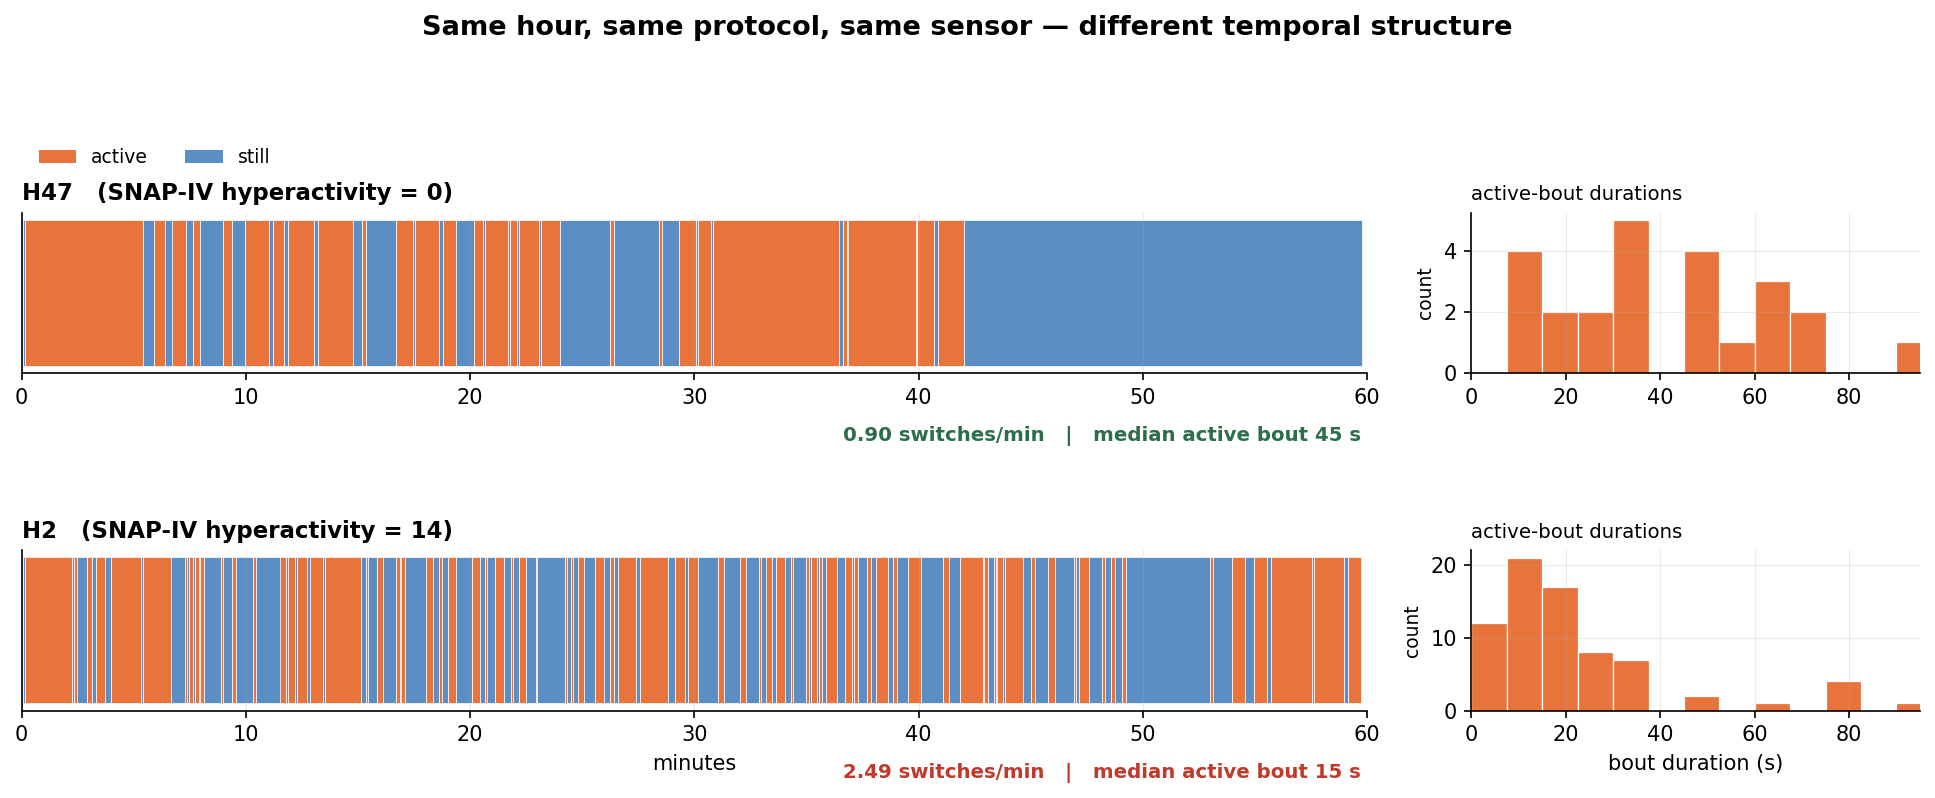

In [45]:
# =============================================================================
#  FIG 0b — THE PHENOMENON: the same hour, two children, opposite ends of SNAP
#  This makes the correlation VISIBLE. No statistics needed to see it.
# =============================================================================
LO, HI = 'H47', 'H2'                        # hyper = 0  vs  hyper = 14

fig, ax = plt.subplots(2, 2, figsize=(13, 5.4),
                       gridspec_kw={'width_ratios': [3, 1]})

for row, (sid, label) in enumerate([(LO, 'SNAP-IV hyperactivity = 0'),
                                    (HI, 'SNAP-IV hyperactivity = 14')]):
    Q = pipeline(sid)

    # ---- left: the bout raster over the hour ----
    for s, d, st in zip(Q['starts'], Q['durs'], Q['states']):
        ax[row, 0].barh(0, d / 60, left=s / 60, height=0.7,
                        color=ACTIVE_C if st else STILL_C, edgecolor='white', lw=0.35)

    n_sw   = len(Q['durs']) - 1
    med    = np.median(Q['durs'][Q['states']])
    permin = n_sw / (Q['t'][-1] / 60)

    ax[row, 0].set_xlim(0, 60); ax[row, 0].set_yticks([])
    ax[row, 0].set_title(f'{sid}   ({label})',
                         loc='left', fontweight='bold', fontsize=11)
    ax[row, 0].text(0.995, -0.42,
                    f'{permin:.2f} switches/min   |   median active bout {med:.0f} s',
                    transform=ax[row, 0].transAxes, ha='right', fontsize=9.5,
                    color='#c0392b' if row else '#2c6e49', fontweight='bold')

    # ---- right: active-bout duration histogram ----
    act = Q['durs'][Q['states']]
    ax[row, 1].hist(act, bins=np.arange(0, 100, 7.5),
                    color=ACTIVE_C, edgecolor='white', lw=.6)
    ax[row, 1].set_xlim(0, 95)
    ax[row, 1].set_ylabel('count', fontsize=9)
    ax[row, 1].set_title('active-bout durations', fontsize=9.5, loc='left')

ax[1, 0].set_xlabel('minutes')
ax[1, 1].set_xlabel('bout duration (s)')

ax[0, 0].legend(handles=[Patch(facecolor=ACTIVE_C, label='active'),
                         Patch(facecolor=STILL_C,  label='still')],
                ncol=2, frameon=False, fontsize=9,
                loc='lower left', bbox_to_anchor=(0, 1.18))

for a in ax.ravel():
    a.spines['top'].set_visible(False)
    a.spines['right'].set_visible(False)

fig.suptitle('Same hour, same protocol, same sensor — different temporal structure',
             fontsize=13, fontweight='bold', y=1.04)
plt.tight_layout()
plt.savefig(FIGS / 'fig0b_phenomenon.png', dpi=190, bbox_inches='tight')
plt.show()